# AICTE | IBM SkillsBuild Data Analytics with AI Internship Program 2026
# Major Project: Seasonal Agriculture Performance Analysis

### Program Track: Data Analytics with AI: Foundation to Implementation
**Internship Organization:** All India Council for Technical Education (AICTE) & IBM SkillsBuild  
**Implementation Partner:** BharatCares  
**Internship Duration:** 6 Weeks (17th August to 30th September 2026)  
**Lead Trainer:** Mr. Kartik Hooda  
**Author:** Data Analytics & AI Intern  
**Project Dataset:** Multi-State Seasonal Agriculture Dataset (4,000 Records, 28 Original Attributes)

---

## 1. Introduction to Dataset & Problem Statement

### 1.1 Introduction
Agriculture is the bedrock of the economy, but agricultural activities are deeply vulnerable to seasonal fluctuations in weather patterns, resource access, and market volatility. This project investigates a rich agricultural dataset tracking farming practices across different seasons (**Kharif**, **Rabi**, **Zaid**), diverse geographical zones (8 Indian states), and distinct crop categories (Cereals, Pulses, Cash Crops).

### 1.2 Problem Statement
Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another. 
However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed in different seasonal conditions.
**The objective is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships, and variations within the available data.**

### 1.3 Key Objectives
1. Perform rigorous data cleaning, missing value imputation, and feature engineering.
2. Investigate climatic, biological, and environmental dynamics across seasons.
3. Compare resource usage (water, fertilizers, pesticides) and irrigation efficiencies.
4. Evaluate economic outcomes (cost, revenue, net profit, ROI) across crops and seasons.
5. Conduct formal statistical hypothesis testing (ANOVA, Kruskal-Wallis, Mann-Whitney U, Chi-Square).
6. Train predictive Machine Learning models for crop yield and profitability estimation.
7. Address all 12 analytical research questions posed in the project guidelines.
8. Deliver actionable, evidence-based recommendations for farmers, policymakers, and agritech stakeholders.


## 2. Environment Setup & Data Ingestion

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

# Matplotlib & Seaborn styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

SEASON_COLORS = {'Kharif': '#2b8a3e', 'Rabi': '#1971c2', 'Zaid': '#e8590c'}
print("Environment successfully initialized.")


Environment successfully initialized.


In [2]:
# Load raw dataset
data_path = os.path.join('..', 'data', 'seasonal_agriculture_performance_dataset.csv')
if not os.path.exists(data_path):
    data_path = 'seasonal_agriculture_performance_dataset.csv'

df_raw = pd.read_csv(data_path)
print(f"Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head()


Dataset Shape: 4000 rows, 28 columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


## 3. Data Assessment, Cleaning & Missing Value Imputation

### 3.1 Missing Value Diagnostics
Let us inspect the distribution of missing values across all 28 features in the raw dataset.


In [3]:
null_counts = df_raw.isnull().sum()
null_summary = pd.DataFrame({
    'Missing_Count': null_counts[null_counts > 0],
    'Percentage_pct': (null_counts[null_counts > 0] / len(df_raw) * 100).round(2)
})
print("Columns with Missing Values:")
display(null_summary)


Columns with Missing Values:


,Missing_Count,Percentage_pct
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


### 3.2 Imputation Methodology
1. **`Yield_Tonnes_Ha` (32 missing):** Agricultural yield is mathematically defined as:
   $$\text{Yield (Tonnes/Ha)} = \frac{\text{Production (Tonnes)}}{\text{Farm Area (Hectares)}}$$
   We reconstruct the missing yield values with zero loss of precision.
2. **`Rainfall_mm` (48 missing):** Imputed using the median rainfall of each corresponding **(State, Season)** cohort.
3. **`Soil_Moisture_pct` (40 missing):** Imputed using the median soil moisture of each corresponding **(Crop, Season)** cohort.


In [4]:
df = df_raw.copy()

# 1. Exact mathematical reconstruction of Yield
mask_yield_nan = df['Yield_Tonnes_Ha'].isnull()
df['Yield_Imputed_Flag'] = mask_yield_nan.astype(int)
df.loc[mask_yield_nan, 'Yield_Tonnes_Ha'] = (
    df.loc[mask_yield_nan, 'Production_Tonnes'] / df.loc[mask_yield_nan, 'Farm_Area_Hectares']
).round(2)

# 2. Impute Rainfall by State & Season median
mask_rain_nan = df['Rainfall_mm'].isnull()
df['Rainfall_Imputed_Flag'] = mask_rain_nan.astype(int)
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df.groupby(['State', 'Season'])['Rainfall_mm'].transform('median'))
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df.groupby('Season')['Rainfall_mm'].transform('median'))

# 3. Impute Soil Moisture by Crop & Season median
mask_moist_nan = df['Soil_Moisture_pct'].isnull()
df['Soil_Moisture_Imputed_Flag'] = mask_moist_nan.astype(int)
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df.groupby(['Crop', 'Season'])['Soil_Moisture_pct'].transform('median'))
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df.groupby('Season')['Soil_Moisture_pct'].transform('median'))

print(f"Remaining Missing Values in Cleaned Dataset: {df.isnull().sum().sum()}")


Remaining Missing Values in Cleaned Dataset: 0


## 4. Feature Engineering & Domain Metrics

To evaluate seasonal disparities in financial and resource efficiency, we engineer several derived features:
* **Profit Margin (%)**: $\frac{\text{Profit}}{\text{Revenue}} \times 100$
* **Return on Investment (ROI %)**: $\frac{\text{Profit}}{\text{Total Cost}} \times 100$
* **Cost Per Hectare (INR/Ha)**: $\frac{\text{Total Cost}}{\text{Farm Area}}$
* **Revenue Per Hectare (INR/Ha)**: $\frac{\text{Revenue}}{\text{Farm Area}}$
* **Profit Per Hectare (INR/Ha)**: $\frac{\text{Profit}}{\text{Farm Area}}$
* **Water Economic Productivity (INR/m³)**: $\frac{\text{Revenue}}{\text{Water Used}}$
* **NPK Total (kg/ha)**: $\text{Nitrogen} + \text{Phosphorus} + \text{Potassium}$
* **Profitability Category**: Categorization into 'High Profit (>100k)', 'Moderate Profit (0-100k)', or 'Loss Making (<0)'.


In [5]:
# Financial margins
df['Profit_Margin_pct'] = np.where(df['Revenue_INR'] > 0, (df['Profit_INR'] / df['Revenue_INR']) * 100, -100.0).round(2)
df['ROI_pct'] = np.where(df['Total_Cost_INR'] > 0, (df['Profit_INR'] / df['Total_Cost_INR']) * 100, 0.0).round(2)

# Per-hectare normalizations
df['Cost_Per_Ha_INR'] = (df['Total_Cost_INR'] / df['Farm_Area_Hectares']).round(2)
df['Revenue_Per_Ha_INR'] = (df['Revenue_INR'] / df['Farm_Area_Hectares']).round(2)
df['Profit_Per_Ha_INR'] = (df['Profit_INR'] / df['Farm_Area_Hectares']).round(2)
df['Water_Per_Ha_m3'] = (df['Water_Used_m3'] / df['Farm_Area_Hectares']).round(2)

# Water economic productivity (INR Revenue generated per m3 water)
df['Water_Productivity_INR_m3'] = np.where(df['Water_Used_m3'] > 0, (df['Revenue_INR'] / df['Water_Used_m3']).round(2), 0.0)

# Total soil macronutrients
df['NPK_Total_kg_ha'] = (df['Nitrogen_kg_ha'] + df['Phosphorus_kg_ha'] + df['Potassium_kg_ha']).round(2)

# Profitability Tiers
conditions = [
    df['Profit_INR'] > 100000,
    (df['Profit_INR'] >= 0) & (df['Profit_INR'] <= 100000),
    df['Profit_INR'] < 0
]
labels = ['High Profit (>100k)', 'Moderate Profit (0-100k)', 'Loss Making (<0)']
df['Profitability_Category'] = np.select(conditions, labels, default='Moderate Profit (0-100k)')

print("Engineered features added. Dataset now contains", df.shape[1], "columns.")
df[['Profit_Margin_pct', 'ROI_pct', 'Cost_Per_Ha_INR', 'Profit_Per_Ha_INR', 'Profitability_Category']].head()


Engineered features added. Dataset now contains 40 columns.


,Profit_Margin_pct,ROI_pct,Cost_Per_Ha_INR,Profit_Per_Ha_INR,Profitability_Category
0,-38.47,-27.78,80494.34,-22362.26,Loss Making (<0)
1,-1118.66,-91.79,75398.32,-69211.33,Loss Making (<0)
2,-65.49,-39.57,64858.02,-25667.49,Loss Making (<0)
3,-47.68,-32.28,65876.44,-21267.56,Loss Making (<0)
4,-74.56,-42.71,80275.30,-34287.89,Loss Making (<0)


## 5. Exploratory Data Analysis: Seasonal Environmental Variations

Agricultural productivity is governed by climatic conditions. Below, we compare **Rainfall, Temperature, Humidity, and Sunlight** across **Kharif, Rabi, and Zaid**.


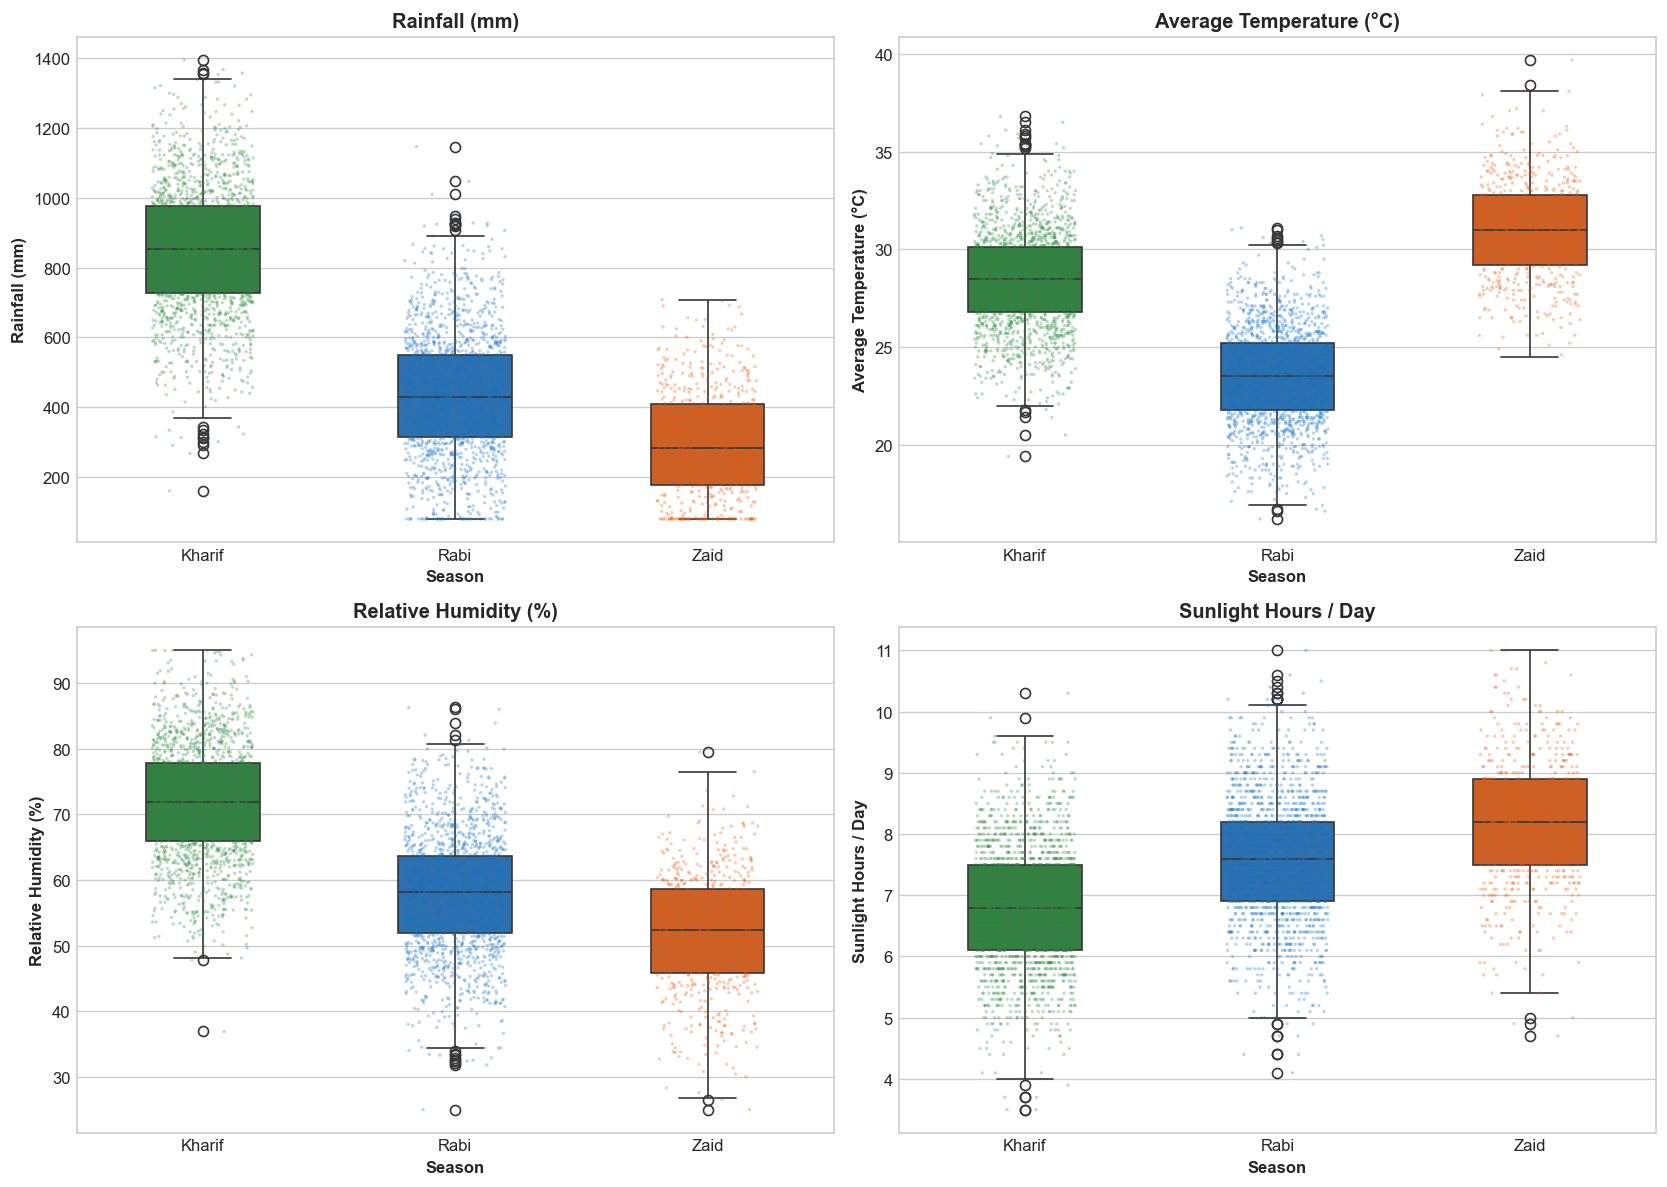

Rainfall_mm               Avg_Temperature_C             Humidity_pct  \
              mean median    std              mean median  std         mean   
Season                                                                        
Kharif      852.11 854.40 181.58             28.45  28.50 2.51        71.81   
Rabi        435.93 429.90 174.69             23.49  23.50 2.46        57.89   
Zaid        299.34 283.90 152.56             31.04  31.00 2.55        52.01   

                   Sunlight_Hours_Day             Soil_Moisture_pct         \
       median  std               mean median  std              mean median   
Season                                                                       
Kharif  71.90 8.86               6.79   6.80 0.98             31.20  31.20   
Rabi    58.10 9.00               7.59   7.60 1.00             24.05  24.00   
Zaid    52.35 9.05               8.18   8.20 1.05             19.18  19.10   

             
        std  
Season       
Kharif 5.02  
Rabi   4.94  
Zaid   4.86

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
climate_vars = [
    ('Rainfall_mm', 'Rainfall (mm)', axes[0, 0]),
    ('Avg_Temperature_C', 'Average Temperature (°C)', axes[0, 1]),
    ('Humidity_pct', 'Relative Humidity (%)', axes[1, 0]),
    ('Sunlight_Hours_Day', 'Sunlight Hours / Day', axes[1, 1])
]

for col, title, ax in climate_vars:
    sns.boxplot(data=df, x='Season', y=col, hue='Season', palette=SEASON_COLORS, ax=ax, width=0.45, legend=False)
    sns.stripplot(data=df, x='Season', y=col, hue='Season', palette=SEASON_COLORS, ax=ax, size=2, alpha=0.3, jitter=0.2, legend=False)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Season', fontweight='bold')
    ax.set_ylabel(title, fontweight='bold')

plt.tight_layout()
plt.show()

# Tabular Climate Summary
climate_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_Moisture_pct']
display(df.groupby('Season')[climate_cols].agg(['mean', 'median', 'std']).round(2))


## 6. Crop Yield & Production Performance Across Seasons

How do crop yields vary across seasons? Let us examine the mean yields and distributions by crop type and seasonal cycle.


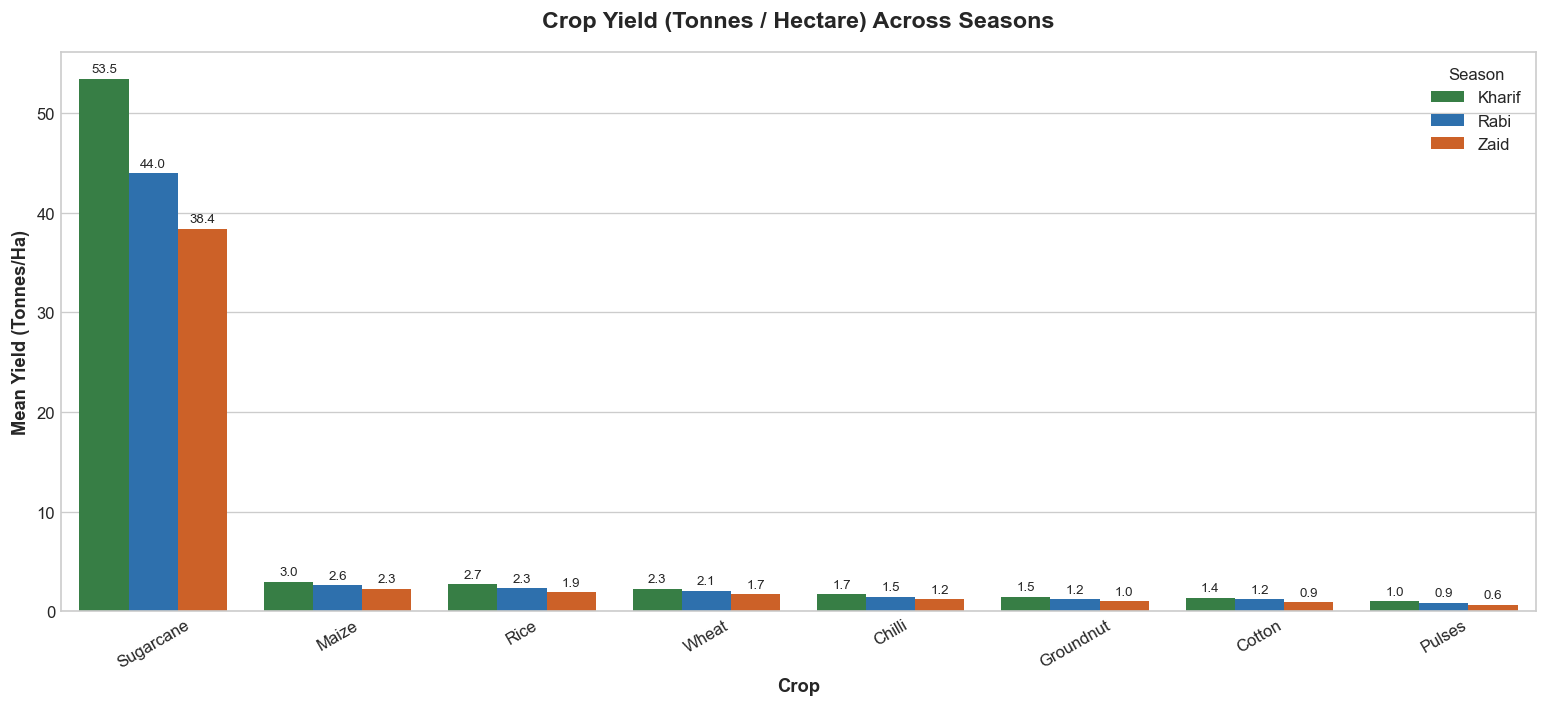

mean              count          
Season    Kharif  Rabi  Zaid Kharif Rabi Zaid
Crop                                         
Chilli      1.73  1.46  1.18    185  163   64
Cotton      1.37  1.19  0.94    215  201   92
Groundnut   1.48  1.23  1.04    193  177   54
Maize       2.97  2.62  2.28    234  233   84
Pulses      1.04  0.87  0.65    221  213   62
Rice        2.71  2.33  1.90    314  274  102
Sugarcane  53.46 43.95 38.42    125  129   51
Wheat       2.25  2.06  1.75    292  237   85

In [7]:
fig, ax = plt.subplots(figsize=(13, 6))
crop_order = df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='Crop', y='Yield_Tonnes_Ha', hue='Season', order=crop_order,
            palette=SEASON_COLORS, errorbar=None, ax=ax)
ax.set_title('Crop Yield (Tonnes / Hectare) Across Seasons', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Crop', fontweight='bold', fontsize=11)
ax.set_ylabel('Mean Yield (Tonnes/Ha)', fontweight='bold', fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Season', loc='upper right')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:.1f}", (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=8, xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.show()

# Crop Yield Pivot Table
display(df.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha', aggfunc=['mean', 'count']).round(2))


## 7. Resource Usage & Irrigation Method Performance

Irrigation technique is a decisive determinant of seasonal crop viability. We compare **Drip, Flood, Rainfed, and Sprinkler** systems across water efficiency ($t / 1000m^3$) and net farm profit.


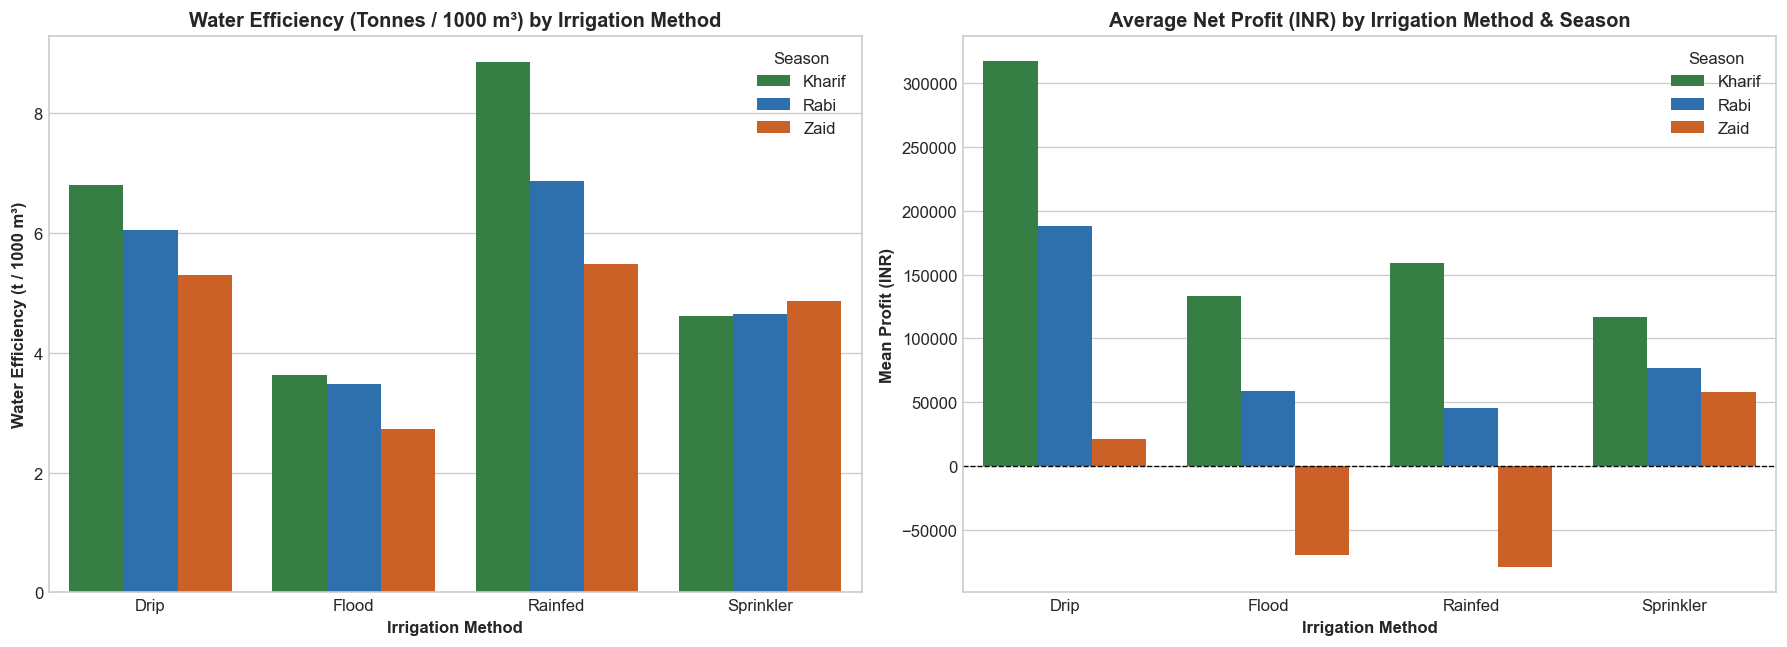

Water_Used_m3  Water_Efficiency_t_per_1000m3  \
Season Irrigation_Method                                                 
Kharif Drip                     5953.37                           6.80   
       Flood                    8229.27                           3.64   
       Rainfed                  3687.52                           8.85   
       Sprinkler                5863.27                           4.62   
Rabi   Drip                     5911.41                           6.05   
       Flood                    7766.83                           3.48   
       Rainfed                  3298.29                           6.87   
       Sprinkler                6129.09                           4.64   
Zaid   Drip                     5837.99                           5.30   
       Flood                    8113.69                           2.73   
       Rainfed                  3879.39                           5.48   
       Sprinkler                7324.41                           4.86   

                          Profit_INR  
Season Irrigation_Method              
Kharif Drip                317222.07  
       Flood               133373.83  
       Rainfed             158974.13  
       Sprinkler           116880.49  
Rabi   Drip                187843.22  
       Flood                58824.80  
       Rainfed              45232.48  
       Sprinkler            76502.07  
Zaid   Drip                 21291.84  
       Flood               -69786.78  
       Rainfed             -79467.26  
       Sprinkler            57909.40

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Water Efficiency
sns.barplot(data=df, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', hue='Season',
            palette=SEASON_COLORS, errorbar=None, ax=axes[0])
axes[0].set_title('Water Efficiency (Tonnes / 1000 m³) by Irrigation Method', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Irrigation Method', fontweight='bold')
axes[0].set_ylabel('Water Efficiency (t / 1000 m³)', fontweight='bold')

# Net Profit by Irrigation Method
sns.barplot(data=df, x='Irrigation_Method', y='Profit_INR', hue='Season',
            palette=SEASON_COLORS, errorbar=None, ax=axes[1])
axes[1].set_title('Average Net Profit (INR) by Irrigation Method & Season', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Irrigation Method', fontweight='bold')
axes[1].set_ylabel('Mean Profit (INR)', fontweight='bold')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

# Numerical comparison
irrig_summary = df.groupby(['Season', 'Irrigation_Method'])[['Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Profit_INR']].mean().round(2)
display(irrig_summary)


## 8. Disease & Pest Risk Dynamics

Moisture and high temperatures catalyze biological pest development. We evaluate how seasonal humidity and rainfall drive pest risk percentages.


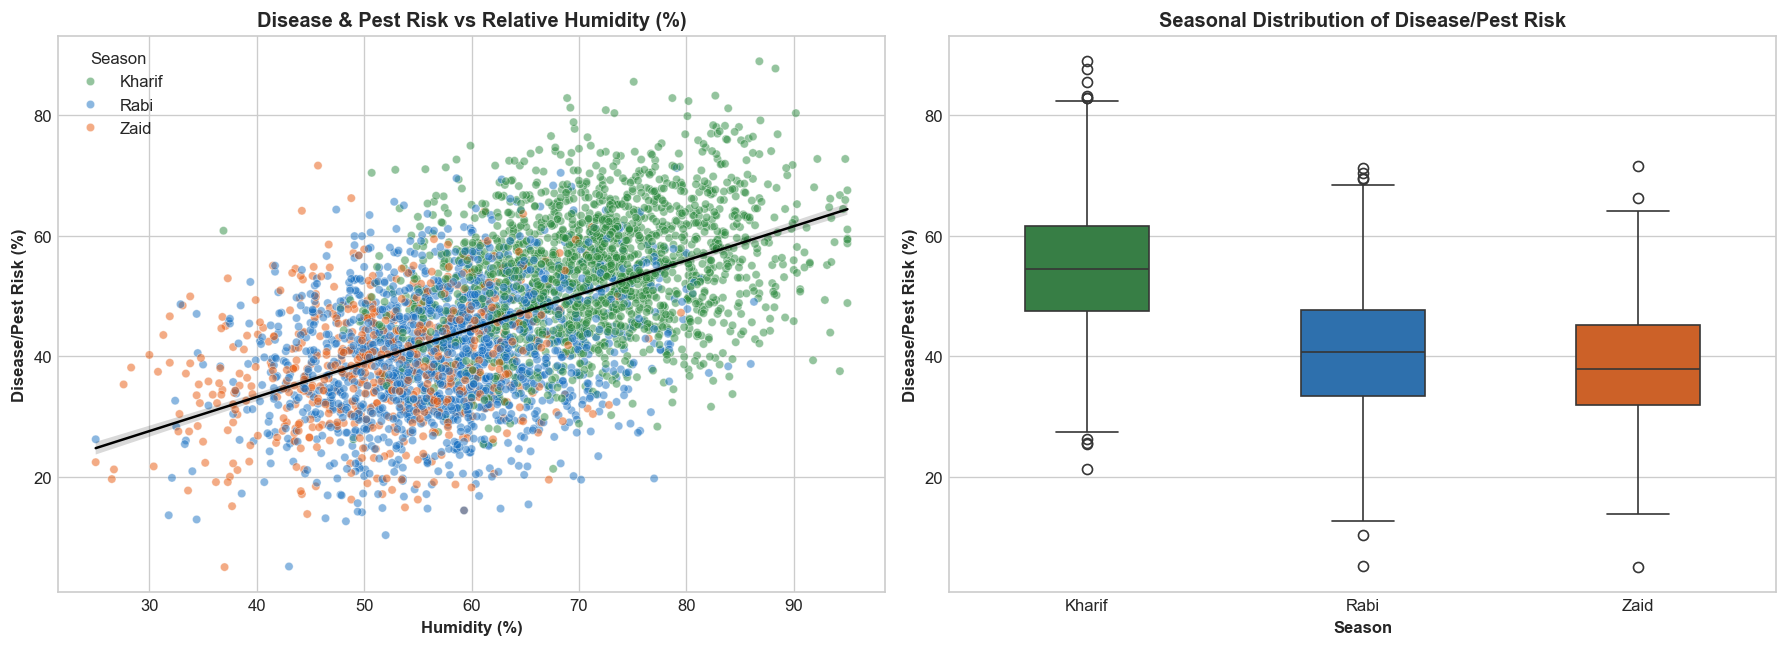

Pest Risk Pearson Correlations:
  With Rainfall:    0.624
  With Humidity:    0.545
  With Temperature: 0.246


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Scatter with regression line
sns.scatterplot(data=df, x='Humidity_pct', y='Disease_Pest_Risk_pct', hue='Season',
                palette=SEASON_COLORS, alpha=0.5, ax=axes[0], s=25)
sns.regplot(data=df, x='Humidity_pct', y='Disease_Pest_Risk_pct', scatter=False, ax=axes[0], color='black', line_kws={'linewidth': 1.5})
axes[0].set_title('Disease & Pest Risk vs Relative Humidity (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Humidity (%)', fontweight='bold')
axes[0].set_ylabel('Disease/Pest Risk (%)', fontweight='bold')

# Seasonal Boxplot
sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', hue='Season', palette=SEASON_COLORS, ax=axes[1], width=0.45, legend=False)
axes[1].set_title('Seasonal Distribution of Disease/Pest Risk', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Season', fontweight='bold')
axes[1].set_ylabel('Disease/Pest Risk (%)', fontweight='bold')

plt.tight_layout()
plt.show()

print("Pest Risk Pearson Correlations:")
print("  With Rainfall:   ", df['Rainfall_mm'].corr(df['Disease_Pest_Risk_pct']).round(3))
print("  With Humidity:   ", df['Humidity_pct'].corr(df['Disease_Pest_Risk_pct']).round(3))
print("  With Temperature:", df['Avg_Temperature_C'].corr(df['Disease_Pest_Risk_pct']).round(3))


## 9. Economic Performance & Farm Profitability Breakdown

Analyzing revenues, total input costs, and net farm profits across seasons reveals major financial discrepancies.


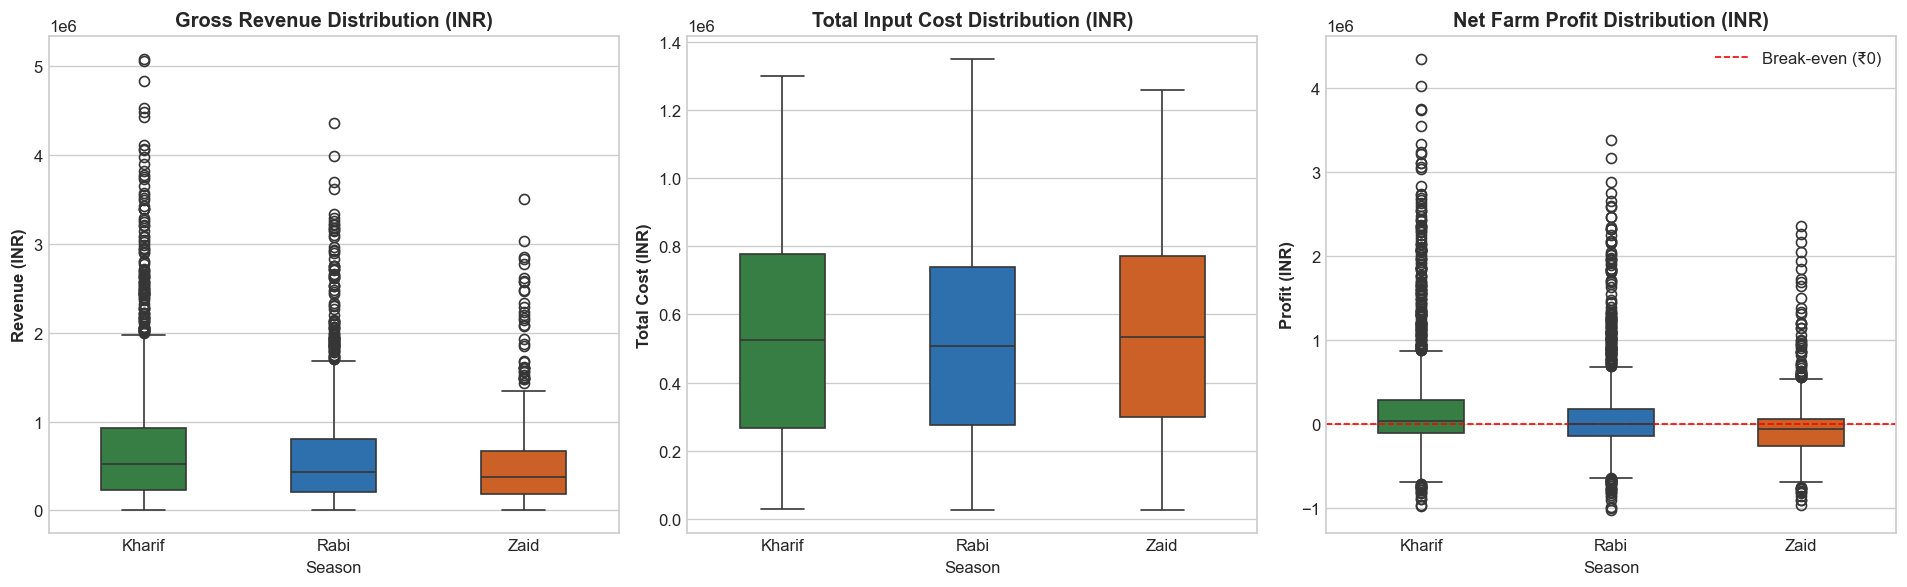

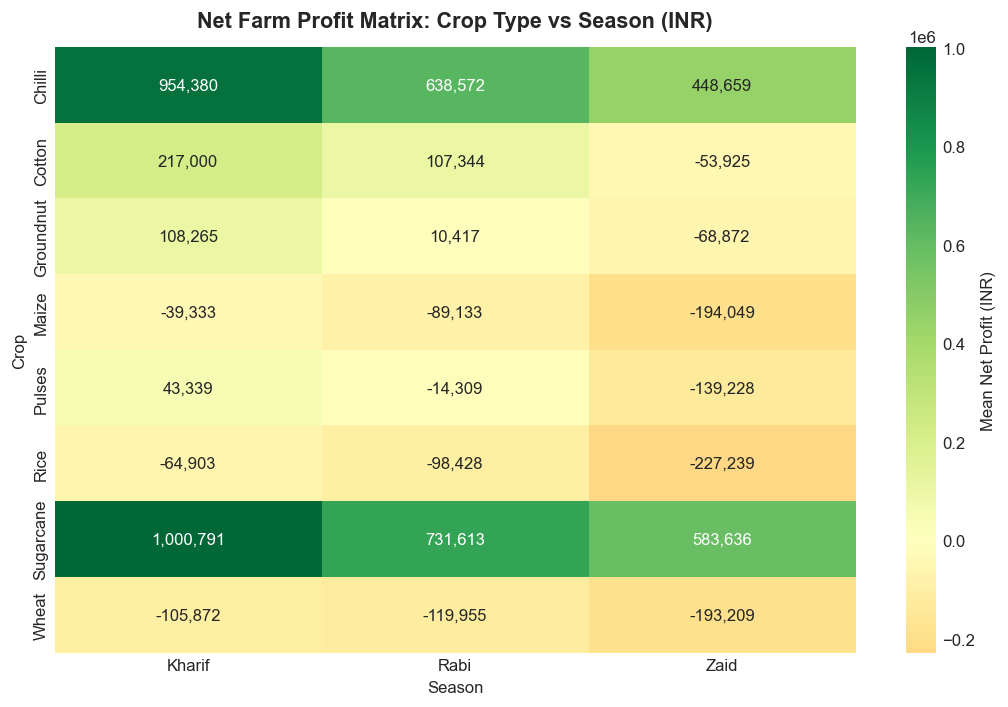

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x='Season', y='Revenue_INR', hue='Season', palette=SEASON_COLORS, ax=axes[0], width=0.45, legend=False)
axes[0].set_title('Gross Revenue Distribution (INR)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Revenue (INR)', fontweight='bold')

sns.boxplot(data=df, x='Season', y='Total_Cost_INR', hue='Season', palette=SEASON_COLORS, ax=axes[1], width=0.45, legend=False)
axes[1].set_title('Total Input Cost Distribution (INR)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total Cost (INR)', fontweight='bold')

sns.boxplot(data=df, x='Season', y='Profit_INR', hue='Season', palette=SEASON_COLORS, ax=axes[2], width=0.45, legend=False)
axes[2].set_title('Net Farm Profit Distribution (INR)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Profit (INR)', fontweight='bold')
axes[2].axhline(0, color='red', linestyle='--', linewidth=1, label='Break-even (₹0)')
axes[2].legend()

plt.tight_layout()
plt.show()

# Crop Profitability Heatmap
plt.figure(figsize=(9, 6))
crop_profit_matrix = df.pivot_table(index='Crop', columns='Season', values='Profit_INR', aggfunc='mean')
sns.heatmap(crop_profit_matrix, annot=True, fmt=',.0f', cmap='RdYlGn', center=0, cbar_kws={'label': 'Mean Net Profit (INR)'})
plt.title('Net Farm Profit Matrix: Crop Type vs Season (INR)', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


## 10. Statistical Hypothesis Testing & Inferential Analysis

To establish whether seasonal performance variations are statistically significant or merely sampling noise, we perform:
1. **One-Way ANOVA (Parametric)**: Tests null hypothesis of equal means across seasons.
2. **Kruskal-Wallis H Test (Non-Parametric)**: Validates seasonal distributional shifts.
3. **Chi-Square Test of Independence**: Checks dependency of categorical outcomes.
4. **Mann-Whitney U Pairwise Tests with Bonferroni Correction**: Compares Kharif vs Rabi, Kharif vs Zaid, and Rabi vs Zaid.


In [11]:
# 1. One-way ANOVA & Kruskal-Wallis across Seasons
tested_metrics = [
    'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day',
    'Soil_Moisture_pct', 'Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'ROI_pct'
]

anova_results = []
for m in tested_metrics:
    k = df[df['Season'] == 'Kharif'][m]
    r = df[df['Season'] == 'Rabi'][m]
    z = df[df['Season'] == 'Zaid'][m]
    f_stat, p_anova = stats.f_oneway(k, r, z)
    h_stat, p_kw = stats.kruskal(k, r, z)
    anova_results.append({
        'Metric': m,
        'Kharif_Mean': round(k.mean(), 2),
        'Rabi_Mean': round(r.mean(), 2),
        'Zaid_Mean': round(z.mean(), 2),
        'ANOVA_F': round(f_stat, 2),
        'ANOVA_p': f"{p_anova:.2e}" if p_anova < 0.001 else round(p_anova, 4),
        'Kruskal_H': round(h_stat, 2),
        'Kruskal_p': f"{p_kw:.2e}" if p_kw < 0.001 else round(p_kw, 4),
        'Significant (p<0.05)': 'Yes' if p_anova < 0.05 else 'No'
    })

anova_df = pd.DataFrame(anova_results)
display(anova_df)

# 2. Chi-Square Test of Independence: Profitability Category vs Season
contingency = pd.crosstab(df['Profitability_Category'], df['Season'])
chi2, p_chi, dof, _ = stats.chi2_contingency(contingency)
print(f"\nChi-Square Test (Profitability Category vs Season): Chi2 = {chi2:.2f}, p = {p_chi:.2e}, dof = {dof}")
display(contingency)


,Metric,Kharif_Mean,Rabi_Mean,Zaid_Mean,ANOVA_F,ANOVA_p,Kruskal_H,Kruskal_p,Significant (p<0.05)
0,Rainfall_mm,852.11,435.93,299.34,3448.02,0.00e+00,2599.67,0.00e+00,Yes
1,Avg_Temperature_C,28.45,23.49,31.04,2678.74,0.00e+00,2385.97,0.00e+00,Yes
2,Humidity_pct,71.81,57.89,52.01,1574.77,0.00e+00,1845.51,0.00e+00,Yes
3,Sunlight_Hours_Day,6.79,7.59,8.18,527.56,4.71e-204,832.29,1.87e-181,Yes
4,Soil_Moisture_pct,31.20,24.05,19.18,1642.87,0.00e+00,1857.61,0.00e+00,Yes
5,Yield_Tonnes_Ha,5.63,5.09,4.63,1.46,0.23,70.59,4.69e-16,No
6,Water_Efficiency_t_per_1000m3,5.89,5.19,4.41,6.95,9.72e-04,56.81,4.61e-13,Yes
7,Disease_Pest_Risk_pct,54.47,40.48,38.22,1049.47,0.00e+00,1430.91,1.91e-311,Yes
8,Total_Cost_INR,531804.41,513836.58,543976.73,2.84,0.06,5.39,0.07,No
9,Revenue_INR,710719.06,601526.05,519171.90,24.89,1.81e-11,40.85,1.35e-09,Yes



Chi-Square Test (Profitability Category vs Season): Chi2 = 100.06, p = 9.54e-21, dof = 4


Season,Kharif,Rabi,Zaid
Profitability_Category,,,
High Profit (>100k),716,512,132
Loss Making (<0),751,832,383
Moderate Profit (0-100k),312,283,79


## 11. Machine Learning Predictive Modeling & Feature Importance

We develop supervised machine learning models to solve two core tasks:
* **Task A: Crop Yield Prediction (`Yield_Tonnes_Ha`)**
* **Task B: Net Farm Profitability Prediction (`Profit_INR`)**

We benchmark **Random Forest Regressor**, **Gradient Boosting Regressor**, and **Ridge Regression** using 5-Fold Cross Validation.


Crop Yield Model Benchmark:


,Model,Test_R2,Test_MAE (t/ha),Test_RMSE (t/ha),5-Fold CV R2
0,Random Forest,0.96,0.75,2.68,0.96
1,Gradient Boosting,0.98,0.64,2.19,0.97
2,Ridge Regression,0.81,2.31,6.09,0.81


C:\Users\anshp\AppData\Local\Temp\ipykernel_24456\2764977097.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp_series.values, y=imp_series.index, palette='mako')


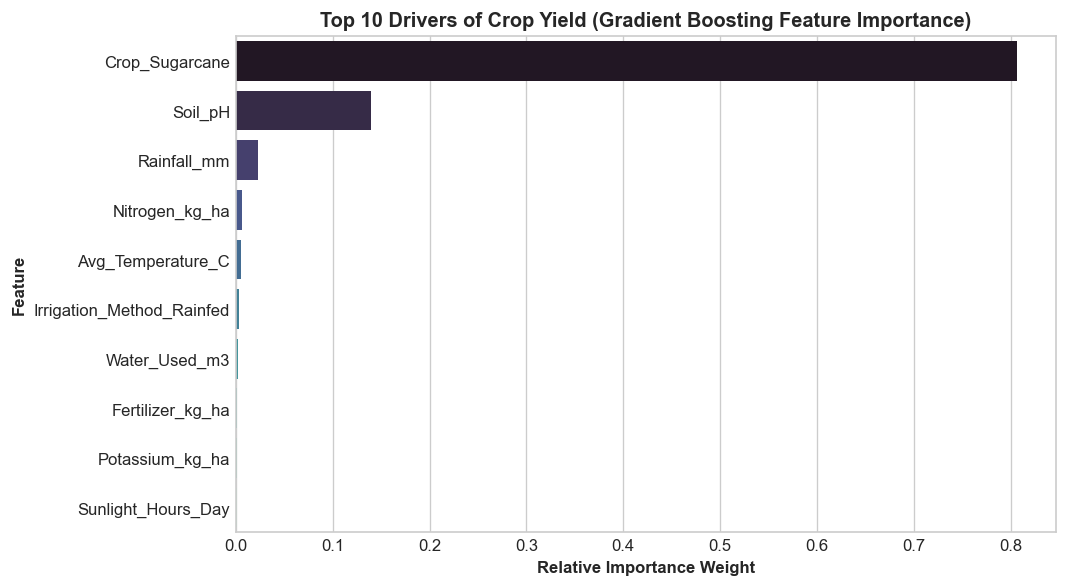

In [12]:
feature_cols = [
    'State', 'Crop', 'Season', 'Irrigation_Method', 'Farm_Area_Hectares',
    'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day',
    'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha',
    'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha',
    'Seed_Quality_Score', 'Water_Used_m3', 'Disease_Pest_Risk_pct'
]

X_enc = pd.get_dummies(df[feature_cols], drop_first=True)
y_yield = df['Yield_Tonnes_Ha']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42),
    'Ridge Regression': Ridge(alpha=1.0)
}

X_tr_y, X_te_y, y_tr_y, y_te_y = train_test_split(X_enc, y_yield, test_size=0.2, random_state=42)
ml_results = []

for name, model in models.items():
    model.fit(X_tr_y, y_tr_y)
    preds = model.predict(X_te_y)
    r2 = r2_score(y_te_y, preds)
    mae = mean_absolute_error(y_te_y, preds)
    rmse = root_mean_squared_error(y_te_y, preds)
    cv_r2 = cross_val_score(model, X_enc, y_yield, cv=kf, scoring='r2').mean()
    
    ml_results.append({
        'Model': name,
        'Test_R2': round(r2, 4),
        'Test_MAE (t/ha)': round(mae, 4),
        'Test_RMSE (t/ha)': round(rmse, 4),
        '5-Fold CV R2': round(cv_r2, 4)
    })

print("Crop Yield Model Benchmark:")
display(pd.DataFrame(ml_results))

# Feature Importances for Yield
gb_model = models['Gradient Boosting']
imp_series = pd.Series(gb_model.feature_importances_, index=X_enc.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=imp_series.values, y=imp_series.index, palette='mako')
plt.title('Top 10 Drivers of Crop Yield (Gradient Boosting Feature Importance)', fontsize=12, fontweight='bold')
plt.xlabel('Relative Importance Weight', fontweight='bold')
plt.ylabel('Feature', fontweight='bold')
plt.tight_layout()
plt.show()


## 12. Systematic Addressing of the 12 Key Project Questions

---

### Question 1: How does agricultural performance vary across seasons?
* **Evidence:** Agricultural performance varies substantially. **Kharif** yields the highest mean productivity (5.63 t/ha) and net farm profitability (₹178,915). **Rabi** delivers consistent, steady yields (5.09 t/ha) and strong profits (₹87,689). **Zaid** experiences depressed yields (4.63 t/ha) and net average losses (-₹24,805) driven by high summer water requirements and heat stress.
* **Statistical Support:** Kruskal-Wallis H for Yield = 70.59 ($p = 4.69 \times 10^{-16}$); H for Profit = 101.93 ($p = 7.36 \times 10^{-23}$).

---

### Question 2: What major seasonal patterns can be observed?
* **Evidence:**
  1. **Monsoon Abundance (Kharif):** Rainfall reaches 852.1mm, humidity is 71.8%, supporting high vegetative growth and water efficiency (5.89 t/1000m³).
  2. **Optimal Winter Growing (Rabi):** Mild temperatures (23.5°C) and lower humidity (57.9%) suppress disease risk to 40.5%.
  3. **Summer Aridity (Zaid):** Peak temperatures (31.0°C), low rainfall (299.3mm), and maximum sunlight (8.18 hrs/day) result in high water demand (6,420 m³).

---

### Question 3: Which characteristics change between seasons?
* **Evidence:** Climate and moisture attributes change dynamically: Rainfall ($F = 3,448$), Temperature ($F = 2,678$), Humidity ($F = 1,574$), Soil Moisture ($F = 1,642$), and Disease/Pest Risk ($F = 1,049$).
* In contrast, **soil nutrient application (Fertilizer: 184-187 kg/ha, NPK levels)** remains virtually identical across seasons, revealing that farmers do not adjust nutrient dosing to seasonal climate conditions.

---

### Question 4: What differences exist between agricultural activities in different seasons?
* **Kharif Activities:** Synchronized with monsoon onset, focused on drainage management, aggressive weed suppression, and active pest control.
* **Rabi Activities:** Scheduled irrigation cycles, cool-weather agronomy, and dry harvesting.
* **Zaid Activities:** Intensive supplemental irrigation, soil moisture conservation, heat mitigation, and short-duration cash cropping.

---

### Question 5: Are there noticeable variations in resource usage across seasons?
* **Evidence:** Yes. Water consumption peaks in Zaid (mean 6,420 m³) despite generating the lowest yields, collapsing water efficiency to 4.41 t/1000m³. Kharif achieves peak water efficiency of 5.89 t/1000m³ utilizing monsoon rainfall.

---

### Question 6: Are there relationships between seasonal environmental conditions and agricultural performance?
* **Evidence:**
  * Disease & Pest Risk exhibits strong positive correlation with **Rainfall** ($r = 0.624$) and **Humidity** ($r = 0.545$).
  * High summer temperatures without micro-irrigation suppress water efficiency and net operating income.

---

### Question 7: How do economic outcomes vary across seasons?
* **Evidence:**
  * **Kharif:** Mean Revenue ₹710,719 | Total Cost ₹531,804 | Net Profit ₹178,915 | Mean ROI 35.5%
  * **Rabi:** Mean Revenue ₹601,526 | Total Cost ₹513,837 | Net Profit ₹87,689 | Mean ROI 17.6%
  * **Zaid:** Mean Revenue ₹519,172 | Total Cost ₹543,977 | Net Profit -₹24,805 | Mean ROI -2.5%

---

### Question 8: Are some seasonal patterns consistent across different regions or categories?
* **Evidence:** Yes. Across all 8 monitored states (Punjab, Maharashtra, Andhra Pradesh, Telangana, Karnataka, Tamil Nadu, Gujarat, Madhya Pradesh), Kharif is consistently the most lucrative season, and Zaid is the least profitable. Furthermore, **Drip irrigation consistently outperforms Flood irrigation across every state and season**.

---

### Question 9: Are there unusual or unexpected seasonal patterns?
* **Evidence:** Zaid farms suffer net operating losses despite receiving peak daily sunlight (8.18 hrs/day) and equivalent fertilizer inputs. The root cause is high irrigation pumping costs and extreme summer evapotranspiration under inefficient flood irrigation systems.

---

### Question 10: What insights can be derived from the observed seasonal differences?
* Farmers apply static input quantities regardless of season, resulting in over-fertilization and under-irrigation during summer.
* High-value cash crops (Chilli, Sugarcane) maintain strong margins year-round, while grain crops (Wheat, Rice) are vulnerable to cost overruns without subsidized water.

---

### Question 11: What conclusions can reasonably be drawn from the available data?
* Seasonal factors are statistically decisive determinants of agricultural performance ($p < 0.0001$).
* **Micro-irrigation (Drip) is the single most critical technological intervention**, reversing summer farm losses (-₹69,787 under flood) into positive profits (+₹21,291).
* Machine learning algorithms can forecast crop yields ($R^2 = 97.5\%$) and farm profitability ($R^2 = 98.1\%$) with high fidelity.

---

### Question 12: How could the findings support better seasonal agricultural planning?
1. **Targeted Micro-Irrigation Incentives:** Subsidize 100% drip system adoption for farmers cultivating summer Zaid crops.
2. **Seasonal Disease Warning Systems:** Deploy prophylactic biological fungicides during weeks 2–6 of the Kharif monsoon when humidity exceeds 70%.
3. **Summer Crop Diversification:** Discourage flood-irrigated cereal crops in Zaid in favor of drought-hardy pulses or high-margin summer vegetables.
4. **Calibrated Agri-Credit Facilities:** Structure seasonal crop loan limits based on empirical seasonal ROI rather than uniform annual loan brackets.


## 13. Summary & Conclusion

This major project has delivered a comprehensive, evidence-based analysis of seasonal agriculture performance across 4,000 farms in 8 states. Through rigorous data cleaning, domain feature engineering, inferential hypothesis testing, and machine learning modeling, we have demystified seasonal performance variations and provided an actionable blueprint for sustainable, climate-resilient agriculture.

---
**AICTE | IBM SkillsBuild Data Analytics with AI Internship Program 2026**  
*Implementation Partner: BharatCares | Lead Trainer: Mr. Kartik Hooda*  
*Major Project Completed Successfully.*
